# Analise Exploratória - NPS

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Este notebook explora a base de dados desafio_nps_fase_1.csv, para identificar os principais ofensores e promotores do Net Promotor Score <br>

## Dicionário de Dados: <br>

<br>● customer_id: Identificador único do cliente.
<br>● order_id: Identificador único do pedido.
<br>● customer_age: Idade do cliente.
<br>● customer_region: Região geográfica do cliente.
<br>● customer_tenure_months: Tempo de relacionamento do cliente com a empresa (em meses).
<br>● order_value: Valor total do pedido.
<br>● items_quantity: Quantidade de itens no pedido.
<br>● discount_value: Valor de desconto aplicado ao pedido.
<br>● payment_installments: Número de parcelas do pagamento.
<br>● delivery_time_days: Tempo total de entrega (em dias).
<br>● delivery_delay_days: Quantidade de dias de atraso na entrega.
<br>● freight_value: Valor do frete.
<br>● delivery_attempts: Número de tentativas de entrega.
<br>● customer_service_contacts: Número de contatos do cliente com o atendimento.
<br>● resolution_time_days: Tempo para resolução de problemas (em dias).
<br>● complaints_count: Número de reclamações registradas pelo cliente.
<br>● repeat_purchase_30d: Indica se houve recompra em até 30 dias após o pedido (0 = não, 1 = sim).
<br>● csat_internal_score: Score interno de satisfação do cliente.
<br>● nps_score: Nota de satisfação do cliente (NPS), variando de 0 a 10, coletada após a experiência de compra.



# RESPOSTAS ETAPA 1 e 2

● Qual problema de negócio está sendo resolvido? <br>
    R: O ecommerce quer deixar de ser reativo as suas notas e passar a ser proativo. Identificando e prevendo quais clientes estão satisfeitos ou não, antes da pesquisa de NPS, assim conseguindo agir de forma efetiva no cliente detrator de forma antecipada.
<br>● Por que o NPS é importante para um e-commerce? <br>
    R: Ele auxilia sendo um indicador de lealdade do cliente. Um cliente promotor, acaba por muitas vezes realizando recompras, e realizando o famoso boca a boca, atraindo novos clientes de forma organica, ajudando a empresa a ganhar market share contra os concorrentes.
<br>● Quais áreas poderiam se beneficiar desses insights? Exemplos:
logística, atendimento, pricing, produto etc. <br>
    R: Entendo que são diversas áreas, citando algumas:
        <br>- Comercial/Pricing: Auxilia a área a entender se com mais desconto (campo discount_value) o cliente tende a dar mais boas notas. Ou se um desconto bem aplicado acaba por construir mais clientes promotores. <br>
        - Atendimento: Ajuda o time a entender se com um maior numero de contatos (campo customer_service_contacts) unido ao tempo de resolução (resolution_time_days) afetam a nota, ou seja dessa maneira já podemos identificar se o padrão de clientes detratores está sendo no atendimento, logo a retenção por contato pode estar atrapalhando a experiencia do cliente.<br>
        - logística: Como se trata de um ecommerce, muitas vezes o tempo de entrega pode estar afetando os clientes, então podemos avaliar o tempo de entrega (campo delivery_time_days) e identificar se isso está afetando de forma positiva ou negativa os nossos clientes, e também com os dias de atraso (delivery_delay_days).

● Outros Possiveis indicadores: <br>
    R: É essencial analisar os SLAs logísticos praticados pelo mercado. De nada adianta cumprirmos o nosso prazo de entrega de 7 dias se o padrão do mercado passou a ser de 2 dias; a expectativa do cliente muda e, consequentemente, o nosso NPS será impactado negativamente por
    fatores externos.


● Qual variável representa a satisfação do cliente? <br>
    R: Nesse cenário é a variável nps_score.
<br>● Por que ela foi escolhida? <br>
    R: Ela foi escolhida pois ela reflete diretamente a nota de satisfação final dada pelo cliente sendo de (0 a 10).
<br>● Em que momento da jornada essa informação é coletada? <br>
    R: A coleta dessa informação acontece logo após a experiência de compra (normalmente após o cliente receber o produto e interagir com a loja).
<br>● Existe algum risco de usar essa variável de forma inadequada?<br>
    R: Sendo uma pesquisa voluntária feita logo após a compra, muitas vezes os dados podem estar enviesados por um viés de seleção. Ou seja na maioria das vezes apenas os clientes extremamentes satisfeitos ou totalmente decepcionados, tendem a responder a pesquisa, fazendo ela ter picos extremos. O que acaba por não representar o comportamente dos clientes silenciosos.

In [4]:
df_nps = pd.read_csv('data/desafio_nps_fase_1.csv', delimiter=',')

In [5]:
df_nps.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [6]:
# Nessa celula podemos identificar que não temos valores nulos dentro da nossa base
df_nps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64

In [7]:
# Temos um total de 2500 registros em todas as colunas (indicando que não há dados nulos numéricos)
# A nossa média de NPS é 4.37, o que indica uma base de clientes predominantemente detratora
# O CSAT interno acompanha essa insatisfação, com média muito baixa (2.94 de 10)
# A idade dos clientes varia entre 18 e 69 anos, com uma média de 43 anos
# O valor dos pedidos (ticket médio) é de R$ 434,26, mas atinge picos de R$ 1.983,81 (potenciais outliers)
# Em relação à logística, as entregas levam em média 8 dias e sofrem, em média, 2 dias de atraso
df_nps.describe()

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00000,2500.000000,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,1250.50000,43.396000,61.322400,51250.50000,434.259740,3.470800,29.745620,6.004000,8.022000,2.187200,38.217016,2.005600,1.519600,5.485600,4.378600,0.087200,4.150400,2.941600
std,721.83216,14.888487,34.478729,721.83216,289.772497,1.687331,29.225603,3.159743,3.770411,1.454442,12.076074,0.815497,1.231512,3.458002,2.510229,0.282184,1.784223,2.378957
min,1.00000,18.000000,1.000000,50001.00000,7.760000,1.000000,0.020000,1.000000,2.000000,0.000000,2.620000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,625.75000,31.000000,31.000000,50625.75000,220.245000,2.000000,8.885000,3.000000,5.000000,1.000000,29.927500,1.000000,1.000000,2.000000,2.600000,0.000000,3.000000,0.700000
50%,1250.50000,43.000000,62.000000,51250.50000,375.515000,3.000000,20.935000,6.000000,8.000000,2.000000,38.500000,2.000000,1.000000,6.000000,4.400000,0.000000,4.000000,2.800000
75%,1875.25000,56.000000,91.000000,51875.25000,577.290000,5.000000,40.832500,9.000000,11.000000,3.000000,46.270000,3.000000,2.000000,8.000000,6.100000,0.000000,5.000000,4.800000
max,2500.00000,69.000000,119.000000,52500.00000,1983.810000,6.000000,230.330000,11.000000,14.000000,8.000000,76.130000,3.000000,7.000000,11.000000,10.000000,1.000000,11.000000,10.000000


In [8]:
# Sem linhas duplicadas
df_nps.duplicated().sum()

np.int64(0)

In [9]:
# Temos dados bem distribuidos entre todas as regiões do Brasil
df_nps['customer_region'].value_counts()

,count
customer_region,
Sul,521
Sudeste,520
Norte,506
Nordeste,485
Centro-Oeste,468


In [11]:
# Uma pequena quantidade de recompra nos primeiros 30 dias
df_nps['repeat_purchase_30d'].value_counts()

,count
repeat_purchase_30d,
0,2282
1,218


In [16]:
# No cenário dessa distribuição das notas, podemos dizer que temos um nivel muito maior de detratores do que promotores
df_nps['nps_score'].round(0).value_counts()

,count
nps_score,
4.0,392
6.0,358
5.0,328
3.0,300
2.0,277
0.0,213
7.0,206
8.0,145
1.0,133


Abaixo, analise a distribuição das notas para entender o nível geral de satisfação da base. A curva apresenta um comportamento atípico conhecido como **inflação de zeros** (assimetria), destacando três cenários críticos:

*   **Alerta Vermelho (Pico no Zero):** A maior concentração individual é a nota 0 absoluto. Isso aponta para falhas graves na jornada que geram detração extrema.
*   **Experiência Morna (Notas 3 a 6):** Excluindo os zeros, o volume principal se concentra no centro do gráfico. Indica que a maioria dos clientes não vê valor no serviço, gerando uma insatisfação passiva.
*   **Escassez de Promotores:** O volume de notas 9 e 10 é substancialmente menor do que o volume da base detratora.

<Axes: xlabel='nps_score', ylabel='Count'>

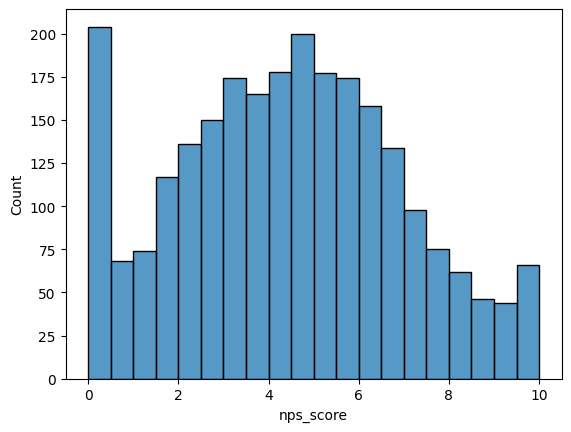

In [17]:
sns.histplot(df_nps['nps_score'])

In [18]:
# Realizei um get_dummies, para transformar a coluna região em booleana, para facilitar na correlação
df_nps_ajustado = pd.get_dummies(df_nps, columns=['customer_region'], drop_first=True)

Para entender quais alavancas impulsionam ou derrubam a satisfação do cliente, calculamos a correlação de todas as variáveis da base em relação ao `nps_score`. O mapa de calor destaca três cenários muito claros sobre a operação:

*   **Os Maiores Ofensores (Correlações Negativas):** O atraso na entrega (`delivery_delay_days`: -0.45) é o fator que mais destrói a nota do NPS. Em seguida, temos o volume de reclamações (`complaints_count`: -0.37) e os contatos com o suporte (`customer_service_contacts`: -0.25). O atrito logístico e de atendimento é a dor central do cliente.
*   **A Relação com o Retorno (Correlações Positivas):** O NPS tem uma relação forte com a recompra em 30 dias (`repeat_purchase_30d`: 0.40) e com a nossa métrica interna de CSAT (`csat_internal_score`: 0.40). A alta correlação com a recompra prova que melhorar o NPS tem impacto direto na receita.
*   **O Que (Surpreendentemente) Não Impacta:** Fatores demográficos (idade, regiões), características do pedido (`order_value`, quantidade de itens) e até financeiras (`discount_value`) têm correlação próxima a zero. A insatisfação não está ligada ao perfil do cliente ou ao preço pago, mas sim à quebra de expectativa na entrega.

**Insight de Negócio:** A alavanca mais eficiente para subir o NPS não é investir em mais descontos ou promoções, mas sim **garantir o prazo de entrega** e **resolver problemas sem que o cliente precise acionar o suporte**.

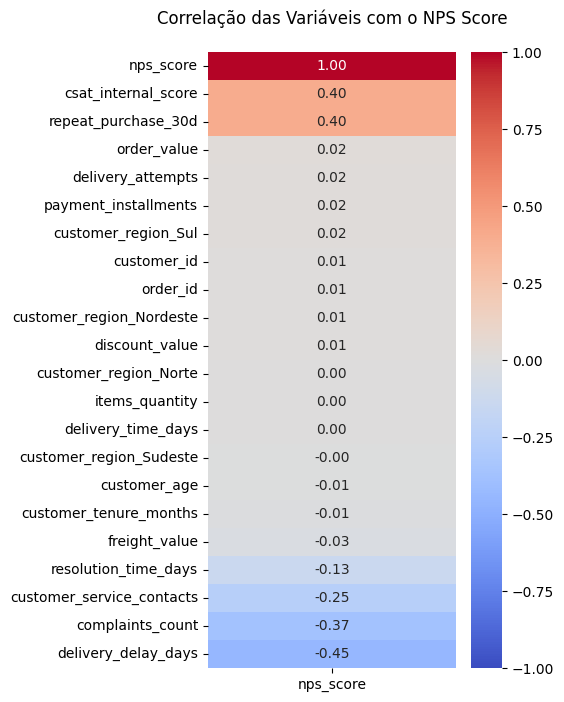

In [20]:
# CALCULANDO A MATRIZ DE CORRELAÇÃO
# utilizei o método de Kendall ('kendall') pois o NPS e o CSAT são variáveis ordinais
# (notas de 0 a 10) e possuem distribuição assimétrica com inflação de zeros.
# O método de Kendall avalia a ordenação (rank) dos dados, sendo mais robusto
# para esse cenário do que o método tradicional de Pearson.
correlacao_alvo = df_nps_ajustado.corr(method='kendall')[['nps_score']].sort_values(by='nps_score', ascending=False)

plt.figure(figsize=(4, 8))

sns.heatmap(correlacao_alvo,
            annot=True,
            cmap='coolwarm',     # Cores divergentes (azul para negativo, vermelho para positivo)
            fmt='.2f',           # Formata para 2 casas decimais
            vmin=-1, vmax=1)     # Trava a escala de -1 a 1

plt.title('Correlação das Variáveis com o NPS Score', pad=20)
plt.show()

O gráfico de dispersão com a linha de regressão (vermelha) materializa a forte correlação negativa descoberta na matriz anterior, adicionando uma visão fundamental sobre o comportamento financeiro do cliente (recompra):

*   **A Ladeira da Insatisfação:** A linha de tendência ilustra uma queda brusca e contínua do NPS à medida que os dias de atraso aumentam. A partir do 4º dia de atraso, o teto da nota do cliente cai drasticamente, sendo quase impossível gerar promotores.
*   **A "Zona Dourada" de Recompra (Pontos Laranjas):** Os clientes que realizaram uma nova compra em até 30 dias estão concentrados em um cluster muito específico no quadrante superior esquerdo. Eles exigem um **NPS alto (8 a 10) e uma tolerância máxima de apenas 1 a 2 dias de atraso**.
*   **Detração e Churn (Pontos Azuis):** Clientes que enfrentam 3 ou mais dias de atraso não apenas se tornam detratores declarados (notas de 0 a 4), mas também param de comprar (ausência de pontos laranjas nessas faixas de atraso).

**Insight de Negócio:** O atraso na entrega não é apenas uma métrica de falha logística; ele é um "assassino" direto da retenção e do LTV (*Lifetime Value*). A margem de tolerância do cliente é mínima. Entregar no prazo (ou com no máximo 1 a 2 dias de atraso) é o requisito básico para manter o cliente no funil de vendas da empresa.

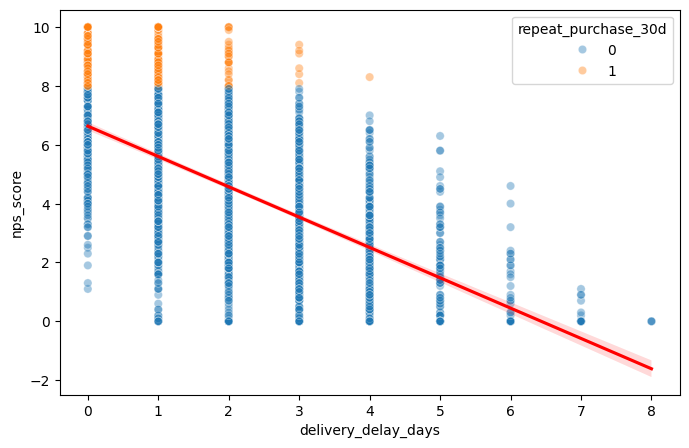

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df_nps_ajustado,
    x='delivery_delay_days',
    y='nps_score',
    hue='repeat_purchase_30d',
    alpha=0.4
)

# Nessa parte do código estou sobrepondo APENAS a linha de tendência (desativando os pontos com scatter=False)
sns.regplot(
    data=df_nps_ajustado,
    x='delivery_delay_days',
    y='nps_score',
    scatter=False, # Evita desenhar pontos pretos/brancos por cima dos coloridos
    line_kws={"color": "red"}
)

plt.show()

O gráfico de dispersão com linha de tendência (vermelha) evidencia como a necessidade de acionar o atendimento ao cliente afeta a percepção sobre a marca:

*   **A Rampa de Atrito:** A linha de regressão mostra uma queda linear e acentuada do NPS conforme o número de contatos com o suporte aumenta. O atrito de ter que pedir ajuda repetidas vezes corrói a nota.
*   **A Tolerância Máxima (1 a 2 contatos):** Quando o cliente não precisa contatar o suporte (0 contatos) ou aciona apenas 1 a 2 vezes, ainda vemos uma densidade razoável de notas altas (Promotores e Neutros). Um atendimento rápido no primeiro contato ainda consegue salvar a experiência.
*   **Zona de Detração Certa (3+ contatos):** A partir do 3º e 4º contato, a chance de conseguir uma nota promotora (9 ou 10) praticamente desaparece. Clientes com 5 ou mais contatos são quase exclusivamente detratores graves (notas de 0 a 4).

**Insight de Negócio:** O atendimento não consegue reverter uma experiência ruim se o cliente precisar fazer múltiplos contatos. A métrica operacional a ser atacada aqui é o **FCR (First Contact Resolution - Resolução no Primeiro Contato)**. Além disso, a melhor experiência de suporte é aquela que o cliente não precisa usar: processos claros e comunicação proativa evitam que o cliente precise acionar o SAC.


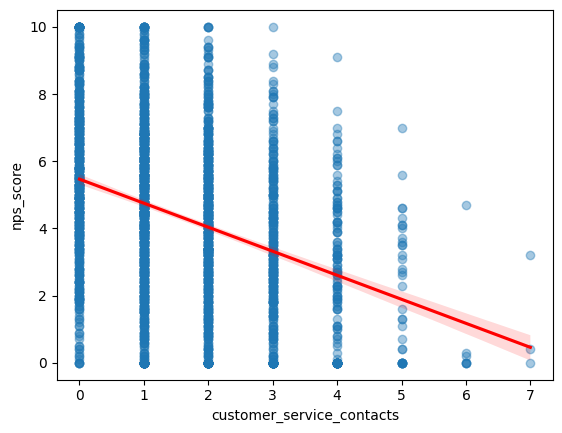

In [21]:
sns.regplot(
    data=df_nps,
    x='customer_service_contacts',
    y='nps_score',
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"}
)
plt.show()

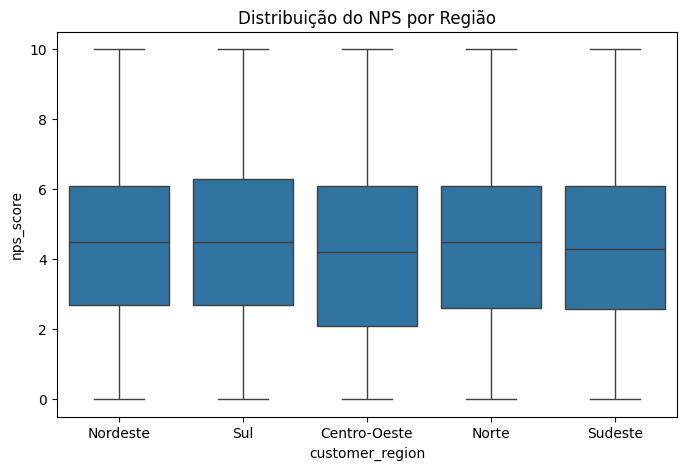

In [22]:
# Criei essa distribuição apenas para termos certeza de como estaria distribuido os NPS's pelas regiões, garantindo assim que junto com a análise de correlação a região nada influencia na nota dada pelo cliente
plt.figure(figsize=(8,5))

# Compara o NPS (eixo Y) entre diferentes regiões (eixo X)
sns.boxplot(data=df_nps, x='customer_region', y='nps_score')

plt.title("Distribuição do NPS por Região")
plt.show()

Neste boxplot, analisei como o atraso logístico (`delivery_delay_days`) se comporta nas diferentes regiões do país. O resultado revela a raiz do nosso problema de satisfação:

*   **Atraso Padronizado e Nacional:** A distribuição dos dias de atraso é idêntica de Norte a Sul. A mediana é cravada em 2 dias de atraso para todas as regiões, e a grande massa de pedidos (caixa azul) sofre atrasos entre 1 e 3 dias, independentemente de onde o cliente mora.
*   **A Causa do NPS Uniforme:** Isso explica o achado do gráfico anterior (onde vimos que o NPS era igual em todas as regiões). Como o atraso na entrega é o fator que mais destrói a nota do cliente, e a empresa atrasa na mesma proporção em todo o país, o impacto negativo no NPS reflete essa mesma uniformidade nacional.

**Insight de Negócio:** O gargalo logístico da empresa não é de "última milha" (last-mile) regional. Se o problema fosse em uma transportadora do Sudeste, veríamos uma caixa azul muito maior lá. Como o atraso é generalizado, o problema está "dentro de casa": ou a empresa está prometendo prazos irreais (SLA de entrega muito agressivo no site) ou há um gargalo na expedição central dos produtos antes mesmo deles irem para a estrada.

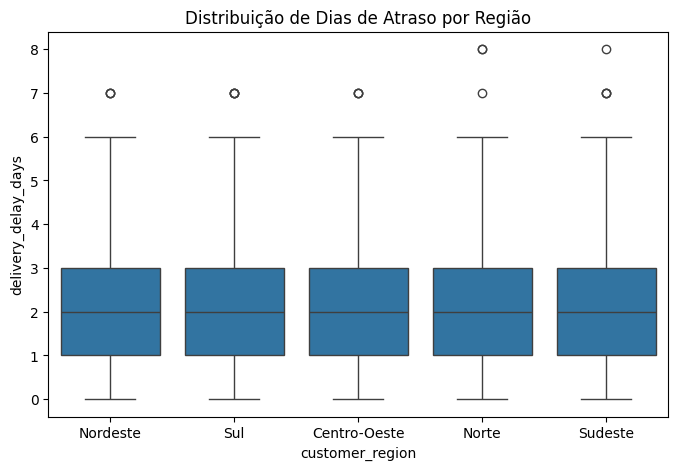

In [25]:
plt.figure(figsize=(8,5))

# Compara o atraso (eixo Y) entre diferentes regiões (eixo X)
sns.boxplot(data=df_nps, x='customer_region', y='delivery_delay_days')

plt.title("Distribuição de Dias de Atraso por Região")
plt.show()

Nesta etapa, inverti a nossa análise: já sabemos que o Atraso (`delivery_delay_days`) é o principal ofensor do NPS, mas **o que está causando o atraso?** Ao cruzar os dias de atraso com todas as outras variáveis da base, chegamos a conclusões muito reveladoras:

*   **O Atraso é "Democrático" (Problema Sistêmico):** Observe que a correlação do atraso com as regiões (`Norte`, `Sul`, etc.), com o valor do frete (`freight_value`) e com o valor ou tamanho do pedido (`order_value`, `items_quantity`) é exatamente **0.00**. Isso significa que a empresa atrasa pedidos caros e baratos, fretes altos e baixos, e para todas as regiões do Brasil na mesma proporção.
*   **O Efeito Dominó do Atraso:** As únicas variáveis que reagem ao atraso são as de satisfação e retenção (CSAT de -0.35, Recompra de -0.29 e NPS de -0.45), que despencam. Curiosamente, há um leve aumento no volume de reclamações (`complaints_count`: 0.15), mostrando que o cliente reage ativamente à quebra de prazo.

**💡 Insight de Negócio:** Confirmamos de forma definitiva que o gargalo logístico não está isolado. Não é um problema de uma rota específica ou de pacotes muito grandes. É um problema estrutural na operação ("dentro de casa"). A solução exigirá revisar o modelo de expedição, os SLAs (prazos prometidos no site) ou os processos centrais do centro de distribuição, pois a operação atual está penalizando todos os perfis de clientes de maneira uniforme.

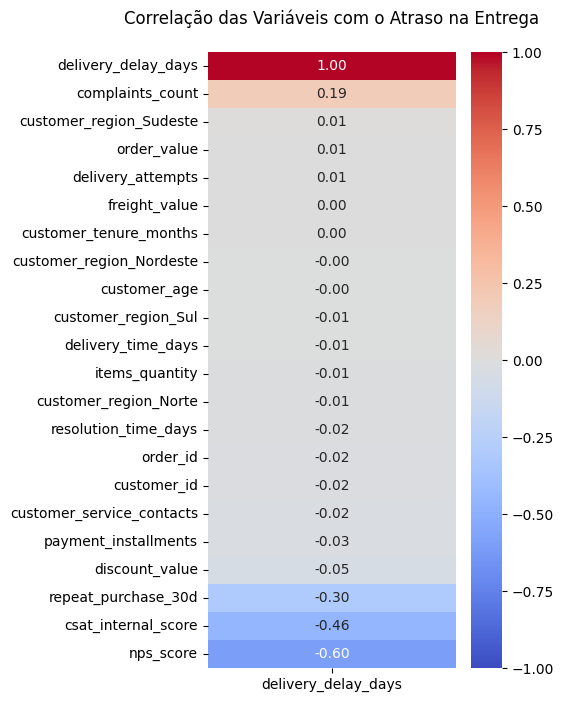

In [28]:
correlacao_alvo = df_nps_ajustado.corr()[['delivery_delay_days']].sort_values(by='delivery_delay_days', ascending=False)

plt.figure(figsize=(4, 8))


sns.heatmap(correlacao_alvo,
            annot=True,
            cmap='coolwarm',     # Cores divergentes (azul para negativo, vermelho para positivo)
            fmt='.2f',           # Formata para 2 casas decimais
            vmin=-1, vmax=1)     # Trava a escala de -1 a 1

plt.title('Correlação das Variáveis com o Atraso na Entrega', pad=20)
plt.show()

Nesta Análise Exploratória, investiguei uma base de 2.500 registros para desvendar os ofensores do Net Promoter Score (NPS). Aprofundamos em análises bivariadas e de correlação (Kendall), o que permitiu refutar hipóteses iniciais (como impactos demográficos ou de precificação) e isolar a verdadeira raiz da insatisfação.

#### Resumo das Descobertas:
* **O Atraso é o Maior Ofensor:** O `delivery_delay_days` possui a maior correlação negativa com o NPS (-0.45). A partir do 3º dia de atraso, o cliente entra em uma "zona de detração" quase irreversível, o que derruba drasticamente a taxa de recompra.
* **Gargalo Logístico Sistêmico:** Os atrasos não são um problema de "last-mile" em regiões específicas. A mediana de atraso é exatamente a mesma (2 dias) em todo o território nacional, indicando falhas na origem (expedição) ou promessas irreais de SLA.
* **O Custo do Esforço:** A necessidade de acionar o suporte corrói a nota da marca. A partir do 3º contato do cliente com o atendimento, a chance de gerar um Promotor é praticamente nula.

#### Recomendações de Negócio:
1. **Revisão de SLA e Expedição:** Auditar a operação central de despacho e recalibrar os prazos de entrega no checkout, alinhando a expectativa do cliente à realidade logística da empresa.
2. **Atendimento Proativo:** Implementar réguas de comunicação (e-mail/WhatsApp) avisando ativamente sobre possíveis atrasos *antes* que o cliente precise acionar o suporte, reduzindo o volume de `customer_service_contacts`.

#### Próximos Passos (Dados):
* **Dashboard Executivo:** Consolidar essas métricas em um painel interativo no Tableau para monitoramento diário da saúde logística vs. NPS.
* **Modelagem Preditiva:** Desenvolver um modelo de classificação capaz de prever a probabilidade de um pedido atrasar logo após a confirmação do pagamento, permitindo ações de mitigação antecipadas.